### Homework 1 - Advanced Microeconomics

### Problem 2.1

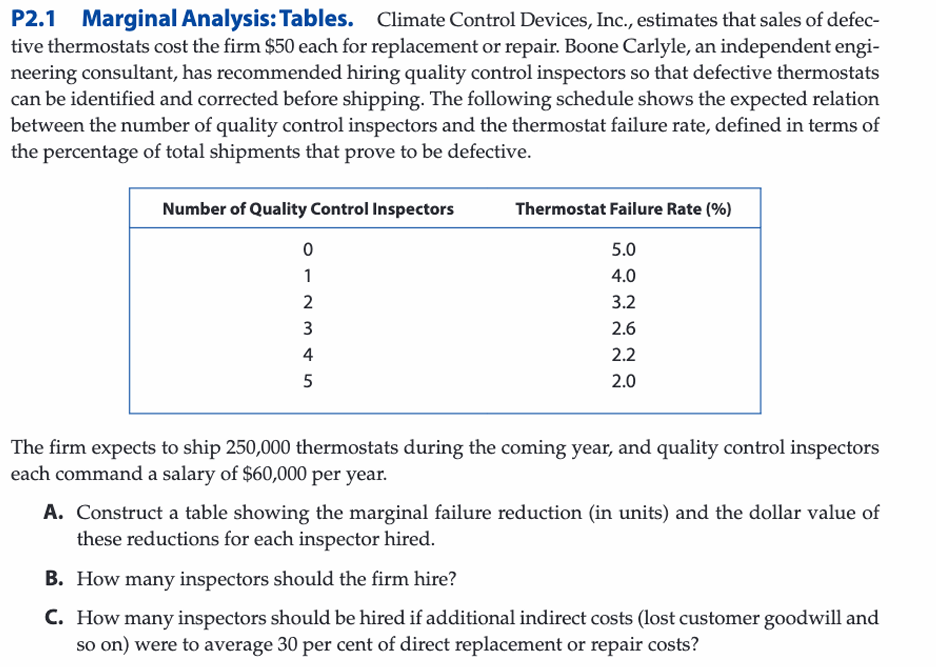

In [1]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.1.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

In [7]:
import pandas as pd 

# Given information 
shipments = 250000
replacement_cost = 50 
inspector_salary = 60000 
indirect_cost_rate = 0.30 

# Number of inspectors 
inspectors  = [0, 1, 2, 3, 4, 5] 

# Failure rate corresponding to each number of inspectors 
failure_rates = [5.0, 4.0, 3.2, 2.6, 2.2, 2.0] 

# Create a DataFrame to organize the data 
df = pd.DataFrame({
    'Inspectors': inspectors,
    'Failure Rate (%)': failure_rates
})

df

,Inspectors,Failure Rate (%)
0,0,5.0
1,1,4.0
2,2,3.2
3,3,2.6
4,4,2.2
5,5,2.0


### a. Marginal Failure Rate

In [8]:
df["Marginal Failure Reduction (%)"] = df["Failure Rate (%)"].diff().fillna(0) * -1 
print(df)

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)
0           0               5.0                            -0.0
1           1               4.0                             1.0
2           2               3.2                             0.8
3           3               2.6                             0.6
4           4               2.2                             0.4
5           5               2.0                             0.2


 The first row is -0.0 because there is no previous row to compare with, so the marginal failure reduction is calculated as 0.

### Calculate defective thermostats avoided  

For example the firm ships 250,000 thermostats, the first inspector reduces failure by 1%

- 250,000 * 0.01 = 2,500 defective thermostats avoided 

In [10]:
df["Defective Thermostats Avoided (units)"] = shipments * df["Marginal Failure Reduction (%)"] / 100
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  
0                                   -0.0  
1                                 2500.0  
2                                 2000.0  
3                                 1500.0  
4                                 1000.0  
5                                  500.0  


### Calculate marginal direct savings

In [ ]:
df["Marginal Direct Savings ($)"] = (df["Defective Thermostats Avoided (units)"] * replacement_cost)   
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  
0                                   -0.0                         -0.0  
1                                 2500.0                     125000.0  
2                                 2000.0                     100000.0  
3                                 1500.0                      75000.0  
4                                 1000.0                      50000.0  
5                                  500.0                      25000.0  


### Calculate marginal net benefits

In [12]:
df["Marginal Net Benefits ($)"] = df["Marginal Direct Savings ($)"] - inspector_salary
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

### Automatically Determine Part B

In [13]:
positive_benefits  = df[df["Marginal Net Benefits ($)"] > 0] 

number_of_inspectors_B = len(positive_benefits) 

print(
    f"Part B: The firm should hire "
    f"{number_of_inspectors_B} inspectors."
)

Part B: The firm should hire 3 inspectors.


### Part C: Include 30% indirect costs 

- Total_cost = Direct_cost * (1 + 0.3) 

In [15]:
df["Savings Including Indirect Costs ($)"] = df["Marginal Direct Savings ($)"] * (1 + indirect_cost_rate)
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

### Calculate net benefits including indirect costs

In [16]:
# calculate net benefits including indirect costs 
df["Net Benefits Including Indirect Costs ($)"] = df["Savings Including Indirect Costs ($)"] - inspector_salary
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

In [17]:
positive_benefits_C = df[
    df["Net Benefits Including Indirect Costs ($)"] > 0
]

number_of_inspectors_C = len(positive_benefits_C)

print(
    f"Part C: The firm should hire "
    f"{number_of_inspectors_C} inspectors."
)

Part C: The firm should hire 4 inspectors.


In [18]:
df.columns.tolist()

['Inspectors',
 'Failure Rate (%)',
 'Marginal Failure Reduction (%)',
 'Defective Thermostats Avoided (units)',
 'Marginal Direct Savings ($)',
 'Marginal Net Benefits ($)',
 'Savings Including Indirect Costs ($)',
 'Net Benefits Including Indirect Costs ($)']

In [19]:
# Final cleaner Table 
display_columns = [
    "Inspectors",
    "Failure Rate (%)",
    "Marginal Failure Reduction (%)",
    "Defective Thermostats Avoided (units)",
    "Marginal Direct Savings ($)",
    "Marginal Net Benefits ($)",
    "Savings Including Indirect Costs ($)",
    "Net Benefits Including Indirect Costs ($)"
]
result = df[display_columns].copy() 
print(result.to_string(index=False)) 

 Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  Marginal Net Benefits ($)  Savings Including Indirect Costs ($)  Net Benefits Including Indirect Costs ($)
          0               5.0                            -0.0                                   -0.0                         -0.0                   -60000.0                                  -0.0                                   -60000.0
          1               4.0                             1.0                                 2500.0                     125000.0                    65000.0                              162500.0                                   102500.0
          2               3.2                             0.8                                 2000.0                     100000.0                    40000.0                              130000.0                                    70000.0
          3               2.6                   

In [23]:
df["Decision_without_Indirect_Costs"] = df["Marginal Net Benefits ($)"].apply(lambda x: "Hire" if x > 0 else "Do Not Hire")

df["Decision_with_Indirect_Costs"] = df["Net Benefits Including Indirect Costs ($)"].apply(lambda x: "Hire" if x > 0 else "Do Not Hire")


print(
    df[[
        "Inspectors",
        "Marginal Net Benefits ($)",
        "Net Benefits Including Indirect Costs ($)",
        "Decision_without_Indirect_Costs",
        "Decision_with_Indirect_Costs"
    ]].to_string(index=False)
)

 Inspectors  Marginal Net Benefits ($)  Net Benefits Including Indirect Costs ($) Decision_without_Indirect_Costs Decision_with_Indirect_Costs
          0                   -60000.0                                   -60000.0                     Do Not Hire                  Do Not Hire
          1                    65000.0                                   102500.0                            Hire                         Hire
          2                    40000.0                                    70000.0                            Hire                         Hire
          3                    15000.0                                    37500.0                            Hire                         Hire
          4                   -10000.0                                     5000.0                     Do Not Hire                         Hire
          5                   -35000.0                                   -27500.0                     Do Not Hire                  Do Not Hire

### Problem 2.2 Incremental Analysis

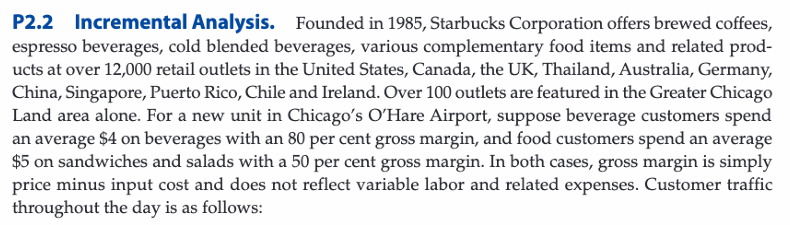

In [26]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.2.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

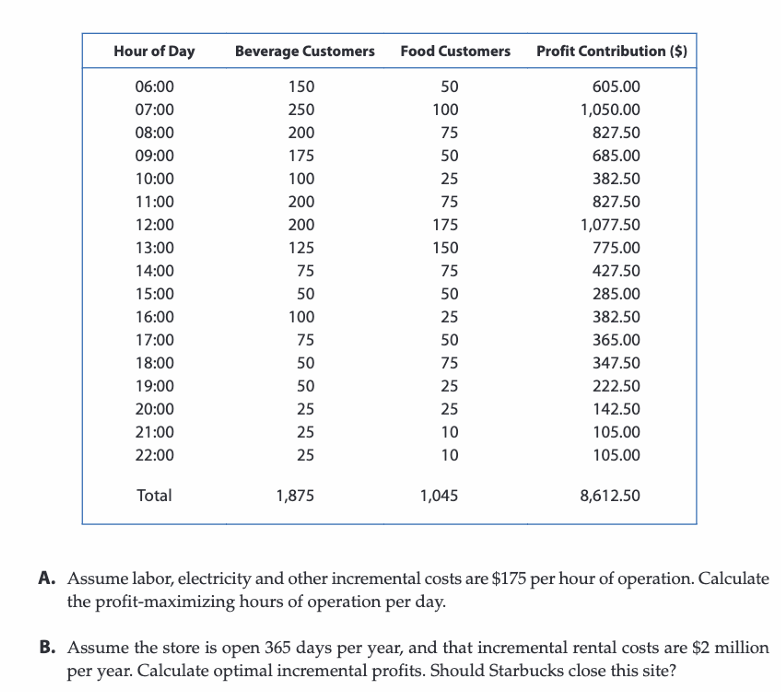

In [27]:
image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.2_part.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

In [28]:
data = {
    "hour":["06:00", "07:00", "08:00", "09:00", "10:00",
        "11:00", "12:00", "13:00", "14:00", "15:00",
        "16:00", "17:00", "18:00", "19:00", "20:00",
        "21:00", "22:00"],
    
    "beverage_customers": [150, 250, 200, 175, 100,
        200, 200, 125, 75, 50,
        100, 75, 50, 50, 25,
        25, 25], 
    
    "food_customers": [50, 100, 75, 50, 25,
        75, 175, 150, 75, 50,
        25, 50, 75, 25, 25,
        10, 10] 
}
df = pd.DataFrame(data)

### Calculate contribution per customer

In [29]:
# Given informations  
beverage_spending = 4 
beverage_margin = 0.80 

food_spending = 5
food_margin = 0.50 

beverage_contribution = beverage_spending * beverage_margin 
food_contribution = food_spending * food_margin  

print("Beverage contribution per customer:", beverage_contribution)
print("Food contribution per customer:", food_contribution)

Beverage contribution per customer: 3.2
Food contribution per customer: 2.5


### Calculate hourly contribution

In [33]:
df["profit_contribution"] = (df["beverage_customers"] * beverage_contribution + df["food_customers"] * food_contribution)
print("Profit contribution per row:", df["profit_contribution"])
print("Total profit contribution:", df["profit_contribution"].sum())

Profit contribution per row: 0      605.0
1     1050.0
2      827.5
3      685.0
4      382.5
5      827.5
6     1077.5
7      775.0
8      427.5
9      285.0
10     382.5
11     365.0
12     347.5
13     222.5
14     142.5
15     105.0
16     105.0
Name: profit_contribution, dtype: float64
Total profit contribution: 8612.5


### Subtract hourly incremental cost

In [34]:
hourly_cost = 175  
df["incremental_profit"] = df["profit_contribution"] - hourly_cost 

df[["hour", "profit_contribution", "incremental_profit"]]  # Display the relevant columns
print("Total incremental profit:", df["incremental_profit"].sum())

Total incremental profit: 5637.5


In [36]:
# Determine whether Starbucks should operate 
df["should_operate"] = df["incremental_profit"] > 0
df[["hour", "incremental_profit", "should_operate"]]  # Display the relevant columns
print(df[["hour", "incremental_profit", "should_operate"]])

     hour  incremental_profit  should_operate
0   06:00               430.0            True
1   07:00               875.0            True
2   08:00               652.5            True
3   09:00               510.0            True
4   10:00               207.5            True
5   11:00               652.5            True
6   12:00               902.5            True
7   13:00               600.0            True
8   14:00               252.5            True
9   15:00               110.0            True
10  16:00               207.5            True
11  17:00               190.0            True
12  18:00               172.5            True
13  19:00                47.5            True
14  20:00               -32.5           False
15  21:00               -70.0           False
16  22:00               -70.0           False


In [37]:
# Calculate total daily incremental profit 
daily_incremental_profit = df.loc[df["should_operate"], "incremental_profit"].sum() 
print(f"Daily incremental profit: {daily_incremental_profit:,.2f}") 
df.loc[df["should_operate"], ["hour", "incremental_profit"]]  # Display the hours when Starbucks should operate
print(df.loc[df["should_operate"], ["hour", "incremental_profit"]])

Daily incremental profit: 5,810.00
     hour  incremental_profit
0   06:00               430.0
1   07:00               875.0
2   08:00               652.5
3   09:00               510.0
4   10:00               207.5
5   11:00               652.5
6   12:00               902.5
7   13:00               600.0
8   14:00               252.5
9   15:00               110.0
10  16:00               207.5
11  17:00               190.0
12  18:00               172.5
13  19:00                47.5


### Part B Annual Incremental Profit

In [38]:
days_per_year = 365 
annual_rent = 2000000 
annual_profit_before_rent = daily_incremental_profit * days_per_year

annual_incremental_profit = annual_profit_before_rent - annual_rent 

print(f"Daily incremental profit: ${daily_incremental_profit:,.2f}")
print(f"Annual profit before rent: ${annual_profit_before_rent:,.2f}")
print(f"Annual incremental profit: ${annual_incremental_profit:,.2f}") 

Daily incremental profit: $5,810.00
Annual profit before rent: $2,120,650.00
Annual incremental profit: $120,650.00


Under the assumptions given, the site produces a positive annual incremental profit
of $120,650 after accounting for annual rent,so the incremental analysis does not support closing the site
based on these calculations.

### Problem 2.6 Profit Maximization Equations

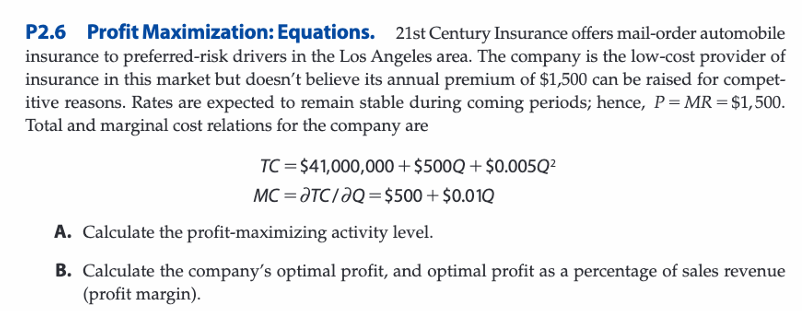

In [39]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.6.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

In [ ]:
# Given informations 
# Price and marginal revenue
#  P=MR=$1,500 
# Total cost 
# TC=41,000,000+500Q+0.005Q^2 
# Marginal cost
# MC=500+0.01Q  
# Define parameters 
P = 1500
MR = P 
# Total cost parameters
TC_fixed = 41000000
TC_variable_intercept = 500
TC_variable_slope = 0.005 
def MC(Q):
    return TC_variable_intercept + 2 * TC_variable_slope * Q 

print(MC(100000)) 

1500.0


In [43]:
Q_star = (MR - TC_variable_intercept) / (2 * TC_variable_slope) 

#Total Revenue 
TR = P * Q_star

#Total Cost
TC = TC_fixed + TC_variable_intercept * Q_star + TC_variable_slope * Q_star**2

#Profit
Profit = TR - TC

# Profit margin 
Profit_margin = Profit / TR

# Marginal Cost at profit-maximizing quantity
MC_at_Q_star = MC(Q_star)

print("=" * 45) 
print("Profit Maximization Summary")
print("=" * 45) 

print(f"Price (P)              : ${P:,.2f}")
print(f"Marginal Revenue (MR)  : ${MR:,.2f}")
print(f"Optimal Quantity (Q*)  : {Q_star:,.0f}")
print(f"Marginal Cost at Q*    : ${MC(Q_star):,.2f}")
print(f"Total Revenue (TR)     : ${TR:,.2f}")
print(f"Total Cost (TC)        : ${TC:,.2f}")
print(f"Optimal Profit         : ${Profit:,.2f}")
print(f"Profit Margin          : {Profit_margin:.2f}%")

Profit Maximization Summary
Price (P)              : $1,500.00
Marginal Revenue (MR)  : $1,500.00
Optimal Quantity (Q*)  : 100,000
Marginal Cost at Q*    : $1,500.00
Total Revenue (TR)     : $150,000,000.00
Total Cost (TC)        : $141,000,000.00
Optimal Profit         : $9,000,000.00
Profit Margin          : 0.06%


### Problem 2.8 Price and Total Revenue

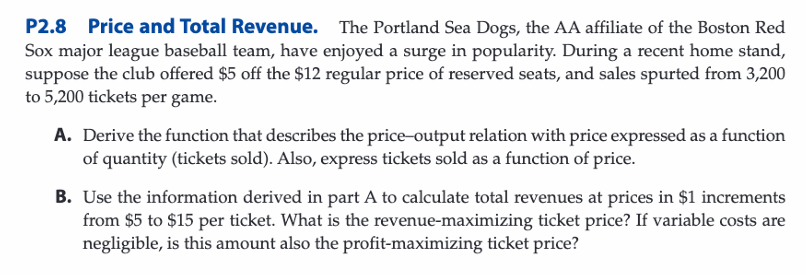

In [44]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.8.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

Deman equation:
P=20.00 + (-0.0025)Q

Verification:
At P = $12 -> Q = 3,200
At P = $7 -> Q = 5,200

Revenue Table:
 Price  Quantity  Total Revenue
     5    6000.0        30000.0
     6    5600.0        33600.0
     7    5200.0        36400.0
     8    4800.0        38400.0
     9    4400.0        39600.0
    10    4000.0        40000.0
    11    3600.0        39600.0
    12    3200.0        38400.0
    13    2800.0        36400.0
    14    2400.0        33600.0
    15    2000.0        30000.0


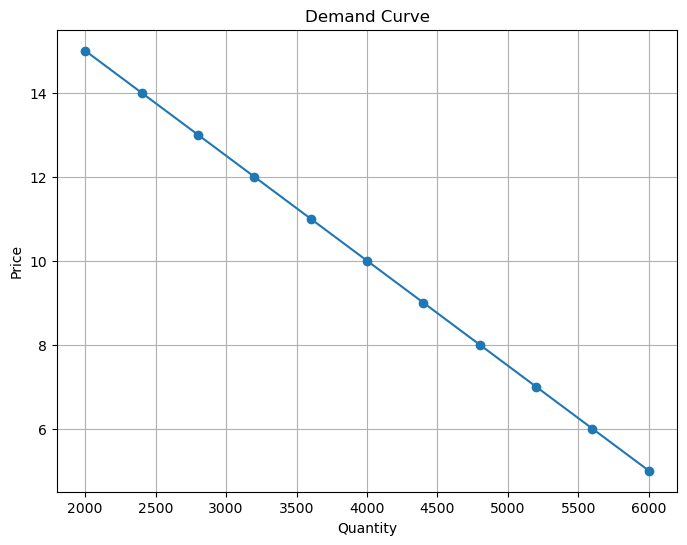

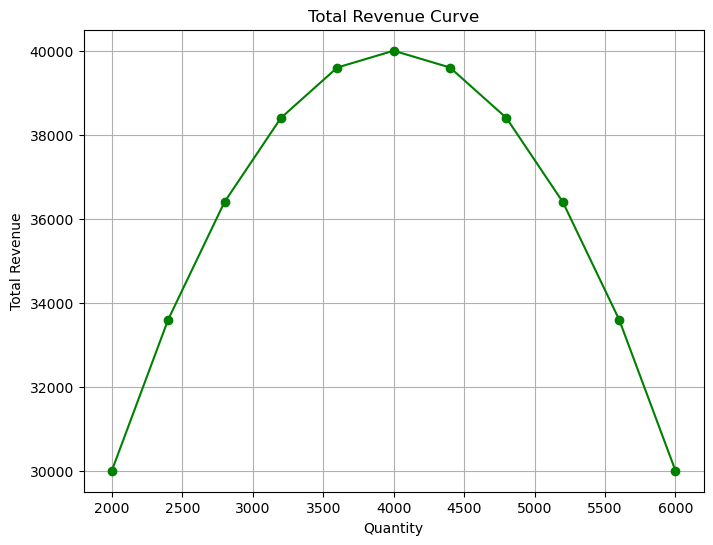

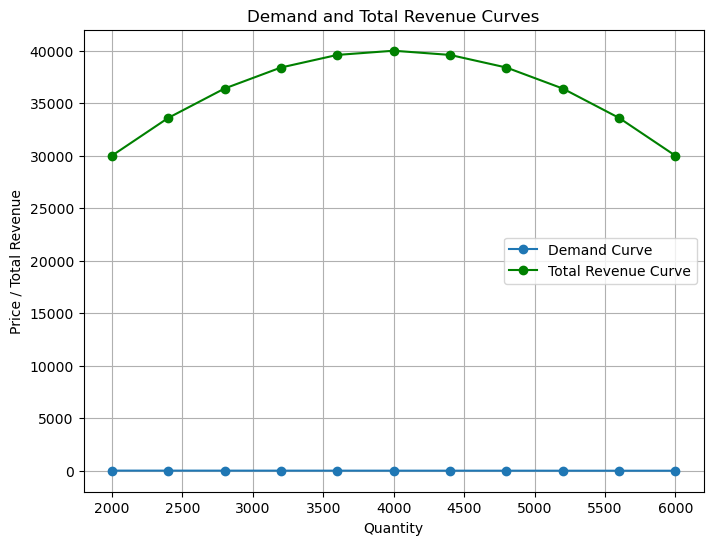


Maximum Revenue:
Quantity: 4,000
Price: $10
Total Revenue: $40,000


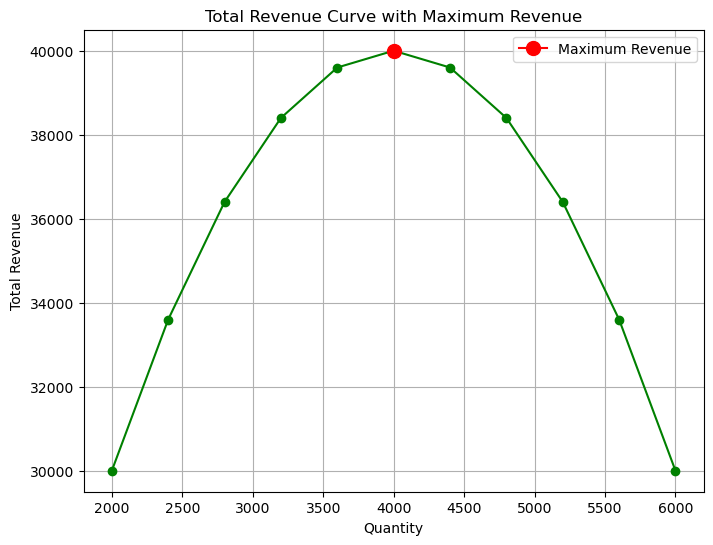

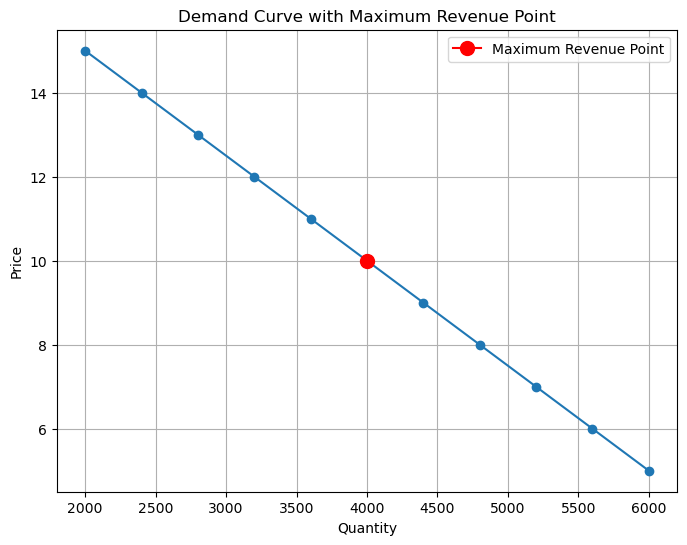

In [ ]:
import pandas as pd 
import numpy as np 
# 1 Observed Data 
P1 = 12 
Q1 = 3200 

P2 = 7
Q2 = 5200 

# Derive demand equation 
# Slope of P as a function of Q 
slope = (P2 - P1) / (Q2 - Q1)
# Intercept of P as a function of Q
intercept = P1 - slope * Q1

print("Deman equation:")
print(f"P={intercept:.2f} + ({slope:.4f})Q")

# Demand functions 
def price_from_quantity(Q):
    return intercept + slope * Q  

def quantity_from_price(P):
    return (P - intercept) / slope 

print("\nVerification:") 
print(f"At P = $12 -> Q = {quantity_from_price(12):,.0f}") 
print(f"At P = $7 -> Q = {quantity_from_price(7):,.0f}") 

prices = np.arange(5, 16, 1) 
quantities = quantity_from_price(prices)  

# total revenue 
total_revenue = prices * quantities

df = pd.DataFrame({
    "Price": prices,
    "Quantity": quantities,
    "Total Revenue": total_revenue
})
print("\nRevenue Table:")
print(df.to_string(index=False)) 

#  the demand curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(quantities, prices, marker='o')
plt.title("Demand Curve")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.grid(True)
plt.show() 

#  the total revenue curve
plt.figure(figsize=(8, 6))
plt.plot(quantities, total_revenue, marker='o', color='green')
plt.title("Total Revenue Curve")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show() 

#  both demand and total revenue curves together
plt.figure(figsize=(8, 6))
plt.plot(quantities, prices, marker='o', label='Demand Curve')
plt.plot(quantities, total_revenue, marker='o', color='green', label='Total Revenue Curve')
plt.title("Demand and Total Revenue Curves")
plt.xlabel("Quantity")
plt.ylabel("Price / Total Revenue")
plt.grid(True)
plt.legend()
plt.show() 

# find maximum revenue
max_revenue_index = np.argmax(total_revenue)
max_revenue_quantity = quantities[max_revenue_index]
max_revenue_price = prices[max_revenue_index]
max_revenue = total_revenue[max_revenue_index]

print("\nMaximum Revenue:")
print(f"Quantity: {max_revenue_quantity:,.0f}")
print(f"Price: ${max_revenue_price}")
print(f"Total Revenue: ${max_revenue:,.0f}") 

# highlight the maximum revenue point on the total revenue curve
plt.figure(figsize=(8, 6))
plt.plot(quantities, total_revenue, marker='o', color='green')
plt.plot(max_revenue_quantity, max_revenue, marker='o', color='red', markersize=10, label='Maximum Revenue')
plt.title("Total Revenue Curve with Maximum Revenue")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.legend()
plt.show()

# highlight the maximum revenue point on the demand curve
plt.figure(figsize=(8, 6))
plt.plot(quantities, prices, marker='o')
plt.plot(max_revenue_quantity, max_revenue_price, marker='o', color='red', markersize=10, label='Maximum Revenue Point')
plt.title("Demand Curve with Maximum Revenue Point")
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()


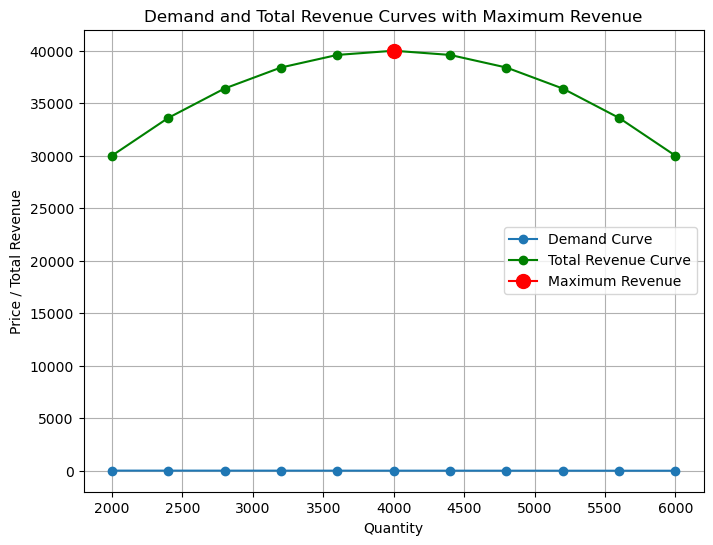

In [ ]:
#  all plots together
plt.figure(figsize=(8, 6))
plt.plot(quantities, prices, marker='o', label='Demand Curve')
plt.plot(quantities, total_revenue, marker='o', color='green', label='Total Revenue Curve')
plt.plot(max_revenue_quantity, max_revenue, marker='o', color='red', markersize=10, label='Maximum Revenue')
plt.title("Demand and Total Revenue Curves with Maximum Revenue")
plt.xlabel("Quantity")
plt.ylabel("Price / Total Revenue")
plt.grid(True)
plt.legend()
plt.show()


### Problem 2.10 Average Cost Minimization

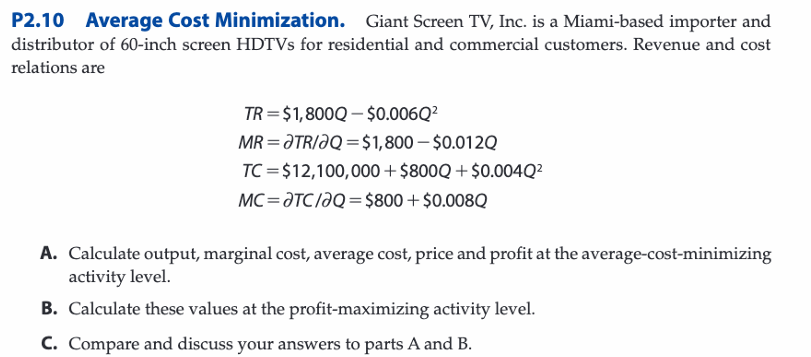

In [47]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.10.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

In [48]:
import numpy as np 
import pandas as pd 

#Revenue  
def TR(Q): 
    return 1800*Q - 0.006*Q**2 

# Marginal Revenue 
def MR(Q):
    return 1800 - 0.012*Q 

# Total Cost 
def TC(Q):
    return 12100000 + 800 *Q + 0.004*Q**2

# Marginal Cost
def MC(Q):
    return 800 + 0.008*Q 

# Average Cost
def AC(Q):
    return TC(Q)/Q 

# Price 
def price(Q):
    return TR(Q)/Q 

# Profit 
def profit(Q):
    return TR(Q) - TC(Q) 

In [49]:
Q_AC = np.sqrt(12100000/0.004)
print(f"Average Cost minimizing quantity: {Q_AC:,.0f}") 

Average Cost minimizing quantity: 55,000


In [52]:
# Q = 55,000 
MC_AC = MC(Q_AC)
print(f"Marginal Cost at Average Cost minimizing quantity: ${MC_AC:,.0f}") 
AC_at_Q_AC = AC(Q_AC)
print(f"Average Cost at Average Cost minimizing quantity: ${AC_at_Q_AC:,.0f}") 
profit_at_Q_AC = profit(Q_AC)
print(f"Profit at Average Cost minimizing quantity: ${profit_at_Q_AC:,.0f}") 
price_at_Q_AC = price(Q_AC)
print(f"Price at Average Cost minimizing quantity: ${price_at_Q_AC:,.0f}")  


Marginal Cost at Average Cost minimizing quantity: $1,240
Average Cost at Average Cost minimizing quantity: $1,240
Profit at Average Cost minimizing quantity: $12,650,000
Price at Average Cost minimizing quantity: $1,470


In [53]:
# profit maximizing output 
Q_profit_max = (1800 - 800)/ (0.008 + 0.012) 
print(f"Profit maximizing quantity: {Q_profit_max:,.0f}") 

MC_at_Q_profit_max = MC(Q_profit_max)
print(f"Marginal Cost at Profit maximizing quantity: ${MC_at_Q_profit_max:,.0f}") 
AC_at_Q_profit_max = AC(Q_profit_max)
print(f"Average Cost at Profit maximizing quantity: ${AC_at_Q_profit_max:,.0f}") 
profit_at_Q_profit_max = profit(Q_profit_max)
print(f"Profit at Profit maximizing quantity: ${profit_at_Q_profit_max:,.0f}") 
price_at_Q_profit_max = price(Q_profit_max)
print(f"Price at Profit maximizing quantity: ${price_at_Q_profit_max:,.0f}") 

Profit maximizing quantity: 50,000
Marginal Cost at Profit maximizing quantity: $1,200
Average Cost at Profit maximizing quantity: $1,242
Profit at Profit maximizing quantity: $12,900,000
Price at Profit maximizing quantity: $1,500


Discussion: 
As we calculate and compare the key metrics for the average cost minimizing output and the profit maximizing output, it is evident that the profit maximizing output results in a higher quantity and price, while the average cost minimizing output achieves lower costs. This highlights the trade-off between minimizing costs and maximizing profits in production decisions.

In practice, firms must carefully consider their production strategies to balance cost efficiency and profit maximization. While minimizing average costs can lead to more efficient resource utilization, it may not always align with the goal of maximizing profits. Conversely, focusing solely on profit maximization might result in higher costs, but it can lead to greater overall profitability. Therefore, understanding the relationship between cost structures and profit potential is crucial for making informed production decisions.